# 1. Imports

In [6]:
import os
import pandas as pd
import numpy as np
from time import time
from glob import glob
from collections import defaultdict as default_dict

# Matplotlib
from matplotlib import pyplot as plt

# Tensorflow
#os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')
from tensorflow.keras import Model, Input
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess_input

# Sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score, davies_bouldin_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Seaborn
import seaborn as sns


# 2. Préparation des données

In [7]:
path = "/content/drive/MyDrive/data/Flipkart"
#path = "./data/Flipkart"

In [8]:
data = pd.read_csv(path+'/cleaned_data.csv')

In [9]:
data.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,...,category,tokenized_description,stemmed_description,combined_postag_wnet,lemmatized_description,lemmatized_description_text,tokenized_product_name,combined_postag_wnet_product_name,lemmatized_product_name,lemmatized_product_name_text
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,...,Home Furnishing,"['key', 'features', 'elegance', 'polyester', '...","['key', 'featur', 'eleg', 'polyest', 'multicol...","[('key', 'n'), ('features', 'v'), ('elegance',...","['key', 'feature', 'elegance', 'polyester', 'm...",key feature elegance polyester multicolor abst...,"['elegance', 'polyester', 'multicolor', 'abstr...","[('elegance', 'n'), ('polyester', 'n'), ('mult...","['elegance', 'polyester', 'multicolor', 'abstr...",elegance polyester multicolor abstract eyelet ...
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,...,Baby Care,"['specifications', 'sathiyas', 'cotton', 'bath...","['specif', 'sathiya', 'cotton', 'bath', 'towel...","[('specifications', 'n'), ('sathiyas', 'n'), (...","['specification', 'sathiyas', 'cotton', 'bath'...",specification sathiyas cotton bath towel bath ...,"['sathiyas', 'cotton', 'bath', 'towel']","[('sathiyas', 'n'), ('cotton', 'n'), ('bath', ...","['sathiyas', 'cotton', 'bath', 'towel']",sathiyas cotton bath towel
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,...,Baby Care,"['key', 'features', 'eurospa', 'cotton', 'terr...","['key', 'featur', 'eurospa', 'cotton', 'terri'...","[('key', 'n'), ('features', 'v'), ('eurospa', ...","['key', 'feature', 'eurospa', 'cotton', 'terry...",key feature eurospa cotton terry face towel se...,"['eurospa', 'cotton', 'terry', 'face', 'towel'...","[('eurospa', 'n'), ('cotton', 'n'), ('terry', ...","['eurospa', 'cotton', 'terry', 'face', 'towel'...",eurospa cotton terry face towel set
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,...,Home Furnishing,"['key', 'features', 'santosh', 'royal', 'fashi...","['key', 'featur', 'santosh', 'royal', 'fashion...","[('key', 'n'), ('features', 'v'), ('santosh', ...","['key', 'feature', 'santosh', 'royal', 'fashio...",key feature santosh royal fashion cotton print...,"['santosh', 'royal', 'fashion', 'cotton', 'pri...","[('santosh', 'n'), ('royal', 'a'), ('fashion',...","['santosh', 'royal', 'fashion', 'cotton', 'pri...",santosh royal fashion cotton print king sized ...
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,...,Home Furnishing,"['key', 'features', 'jaipur', 'print', 'cotton...","['key', 'featur', 'jaipur', 'print', 'cotton',...","[('key', 'n'), ('features', 'v'), ('jaipur', '...","['key', 'feature', 'jaipur', 'print', 'cotton'...",key feature jaipur print cotton floral king si...,"['jaipur', 'print', 'cotton', 'floral', 'king'...","[('jaipur', 'n'), ('print', 'n'), ('

In [10]:
data[['product_category_tree', 'category', 'uniq_id']].head(10)

,product_category_tree,category,uniq_id
0,"[""Home Furnishing >> Curtains & Accessories >>...",Home Furnishing,55b85ea15a1536d46b7190ad6fff8ce7
1,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",Baby Care,7b72c92c2f6c40268628ec5f14c6d590
2,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",Baby Care,64d5d4a258243731dc7bbb1eef49ad74
3,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",Home Furnishing,d4684dcdc759dd9cdf41504698d737d8
4,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",Home Furnishing,6325b6870c54cd47be6ebfbffa620ec7
5,"[""Watches >> Wrist Watches >> Maserati Time Wr...",Watches,893aa5ed55f7cff2eccea7758d7a86bd
6,"[""Watches >> Wrist Watches >> Camerii Wrist Wa...",Watches,f355cc1ccb08bd0d283ed979b7ee7515
7,"[""Watches >> Wrist Watches >> T STAR Wrist Wat...",Watches,dd0e3470a7e6ed76fd69c2da27721041
8,"[""Watches >> Wrist Watches >> Alfajr Wrist Wat...",Watches,41384da51732c0b4df3de8f395714fbb
9,"[""Watches >> Wrist Watches >> TAG Heuer Wrist ...",Watches,710ed5f2393a4b9e8823aa0029f71f93


In [11]:
data[['product_category_tree', 'category', 'uniq_id']].tail(10)

,product_category_tree,category,uniq_id
1040,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,3b465b02720ef7c930cb2e065a8fc05d
1041,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,b1644f47c7dfa58f8c06677f2a27ee09
1042,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,057836ecde71565f8ebdd576e41fdc96
1043,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,38782cce965307ddcdbedfcb7fa409c3
1044,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,be0f39341d771aac57084970f1ed6425
1045,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,958f54f4c46b53c8a0a9b8167d9140bc
1046,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,fd6cbcc22efb6b761bd564c28928483c
1047,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,5912e037d12774bb73a2048f35a00009
1048,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,c3edc504d1b4f0ba6224fa53a43a7ad6
1049,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,f2f027ad6a6df617c9f125173da71e44


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   uniq_id                            1050 non-null   object 
 1   crawl_timestamp                    1050 non-null   object 
 2   product_url                        1050 non-null   object 
 3   product_name                       1050 non-null   object 
 4   product_category_tree              1050 non-null   object 
 5   pid                                1050 non-null   object 
 6   retail_price                       1049 non-null   float64
 7   discounted_price                   1049 non-null   float64
 8   image                              1050 non-null   object 
 9   is_FK_Advantage_product            1050 non-null   bool   
 10  description                        1050 non-null   object 
 11  product_rating                     1050 non-null   objec

In [13]:
data.describe()

,retail_price,discounted_price
count,1049.000000,1049.000000
mean,2186.197331,1584.527169
std,7639.229411,7475.099680
min,35.000000,35.000000
25%,555.000000,340.000000
50%,999.000000,600.000000
75%,1999.000000,1199.000000
max,201000.000000,201000.000000


In [14]:
# Fonction pour convertir un DataFrame en tf.data.Dataset

preprocessor_map = {
    'resnet50': resnet_preprocess_input,
    'vgg16': vgg_preprocess_input
}

def load_img(path, label):
    # Charger l'image depuis le chemin
    img = tf.io.read_file(path)
    # Décoder l'image en tenseur
    img = tf.image.decode_jpeg(img, channels=3)
    # Redimensionner l'image
    img = tf.image.resize(img, [224, 224])

    return img, label

def resnet_preprocess(x, y):

    return resnet_preprocess_input(x), y

def vgg_preprocess(x, y):

    return vgg_preprocess_input(x), y


def df_to_dataset(dataframe, batch_size=32, shuffle=True, encoded_category=False):
    paths = dataframe["imagepath"].values
    labels = dataframe["category"].values
    if encoded_category:
        labels = dataframe["encoded_category"].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))
    ds = ds.cache()
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [15]:
le = LabelEncoder()
data["imagepath"] = data["image"].apply(lambda x: os.path.join(path, 'Images', x))
data['encoded_category'] = le.fit_transform(data['category'])

# Split train/val/test
train_df, temp_df = train_test_split(data, test_size=0.3, stratify=data["category"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.2, stratify=temp_df["category"], random_state=42)

# Transformation du dataframe en tf.data.datset
data_ds = df_to_dataset(data)

In [16]:
'''
images = glob(path+"/Images"+"*/*.jpg")
ids = [os.path.splitext(os.path.basename(fname))[0] for fname in images]

labels = []
for idx in ids:
    label = data.loc[data.uniq_id == idx, 'category'].values[0]
    labels.append(label)


data_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path+"/Images",
    labels=labels,
    image_size=(224,224),
    seed=123,
    batch_size=32,
    shuffle=True,
    verbose=True
)

label_encoder = LabelEncoder()
true_labels = label_encoder.fit_transform(labels)
true_classes = labels
'''

'\nimages = glob(path+"/Images"+"*/*.jpg")\nids = [os.path.splitext(os.path.basename(fname))[0] for fname in images]\n\nlabels = []\nfor idx in ids:\n    label = data.loc[data.uniq_id == idx, \'category\'].values[0]\n    labels.append(label)\n\n\ndata_ds = tf.keras.preprocessing.image_dataset_from_directory(\n    path+"/Images",\n    labels=labels,\n    image_size=(224,224),\n    seed=123,\n    batch_size=32,\n    shuffle=True,\n    verbose=True\n)\n\nlabel_encoder = LabelEncoder()\ntrue_labels = label_encoder.fit_transform(labels)\ntrue_classes = labels\n'

CPU times: user 6.94 s, sys: 1.34 s, total: 8.29 s
Wall time: 35.5 s


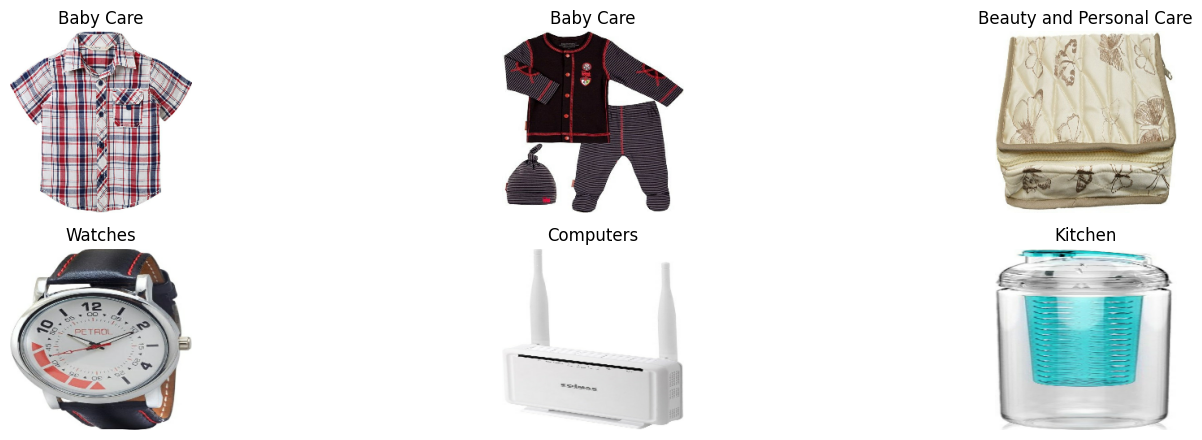

In [17]:
%%time
plt.figure(figsize=(18, 8))
for images, l in data_ds.take(4):
  for i in range(6):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(l[i].numpy().decode('utf-8'))
    plt.axis("off")

# 3. Extraction de caractéristiques via CNN (Transfer Learning)

In [18]:
def extract_features(dataset, model):
    features_list = []
    labels_list = []

    for batch_images, labels in dataset:
        features = model(batch_images, training=False)
        features_list.append(features)
        labels_list.append(labels.numpy())

    # Concaténer tous les batches
    features_array = np.concatenate(features_list, axis=0)
    labels_array = np.concatenate(labels_list, axis=0)

    return features_array, labels_array

In [19]:
results = default_dict(dict)

## 3.1. Extraction des features avec ResNet50

In [20]:
resnet50_data_ds = data_ds.map(resnet_preprocess)

In [21]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
base_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [22]:
%%time
resnet50_features, _ = extract_features(resnet50_data_ds, base_model)

CPU times: user 4min 11s, sys: 35.4 s, total: 4min 46s
Wall time: 50.4 s


In [23]:
print("Data features shape:", resnet50_features.shape)

Data features shape: (1050, 2048)


### 3.1.1. Réduction de dimensions

#### | PCA

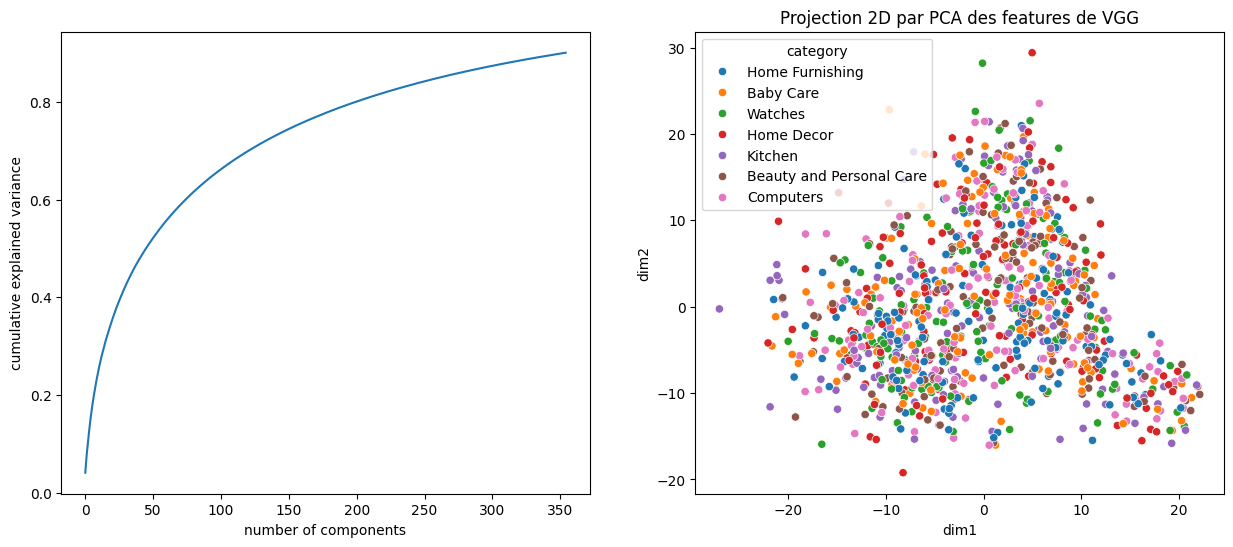

CPU times: user 4.27 s, sys: 23.4 ms, total: 4.29 s
Wall time: 759 ms


In [24]:
%%time
fig = plt.figure(figsize=(15,6))

scaler = StandardScaler()
pca = PCA(n_components=0.90)

scaled_resnet50_features = scaler.fit_transform(resnet50_features)
resnet50_X_pca = pca.fit_transform(scaled_resnet50_features)

df_viz = pd.DataFrame()
df_viz['dim1'] = resnet50_X_pca[:,0]
df_viz['dim2'] = resnet50_X_pca[:,1]
df_viz['category'] = data.category.tolist()

ax = fig.add_subplot(121)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')

ax = fig.add_subplot(122)
sns.scatterplot(x='dim1', y='dim2', hue='category', data=df_viz)
plt.title("Projection 2D par PCA des features de VGG")

plt.show()

In [25]:
resnet50_X_pca

array([[ -4.0794744 ,  12.46985   ,   2.119293  , ...,  -0.20663017,
         -1.5685818 ,  -0.42569086],
       [ 11.671657  ,  -1.3942615 ,  -0.78216285, ...,   1.8185346 ,
         -0.6427749 ,  -0.14461629],
       [-11.057367  , -10.986656  ,  -3.0594802 , ...,   1.1541103 ,
         -0.03133676,  -0.08851859],
       ...,
       [  5.356984  ,  -0.7649221 ,  -7.6305127 , ...,  -0.90060043,
         -0.4507408 ,   0.6338297 ],
       [ -2.4243052 ,  17.541033  ,  -1.3446621 , ...,   0.49064824,
          0.54700327,   0.17657398],
       [  2.684585  ,   1.3275263 ,  -3.209735  , ...,   0.5276462 ,
          0.5463404 ,   1.8098975 ]], dtype=float32)

#### | TSNE

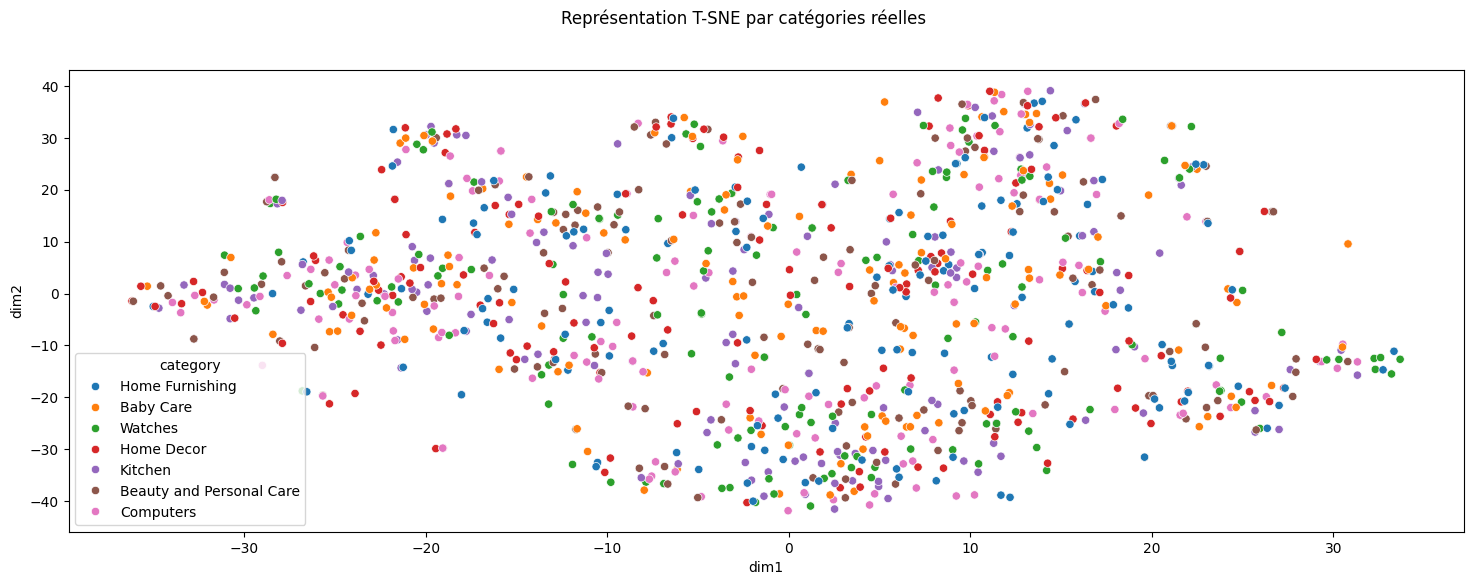

CPU times: user 12.3 s, sys: 14.7 ms, total: 12.3 s
Wall time: 3.04 s


In [26]:
%%time
fig = plt.figure(figsize=(18, 6))
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
resnet50_X_tsne = tsne.fit_transform(resnet50_X_pca)

df_viz = pd.DataFrame()
df_viz['dim1'] = resnet50_X_tsne[:,0]
df_viz['dim2'] = resnet50_X_tsne[:,1]
df_viz['category'] = data.category.tolist()

#ax = fig.add_subplot(121)
sns.scatterplot(x='dim1', y='dim2', hue='category', data=df_viz)

plt.suptitle("Représentation T-SNE par catégories réelles")
plt.show()

In [27]:
resnet50_X_tsne[:2]

array([[-21.797945,  31.579023],
       [  6.727487,  15.103921]], dtype=float32)

### 3.1.2. Kmeans clustering

In [28]:
def tsne_visu_fct(X_tsne, y_cat_num, labels, ARI):
    fig = plt.figure(figsize=(15,6))
    ax = fig.add_subplot(121)

    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=y_cat_num, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(y_cat_num), loc="best", title="Categorie")
    plt.title(f"Représentation des produits par catégories réelles")

    ax = fig.add_subplot(122)
    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=labels, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(labels), loc="best", title="Clusters")
    plt.title(f"Représentation des produits par clusters => ARI={ARI}")
    plt.show()

ARI :  0.0011


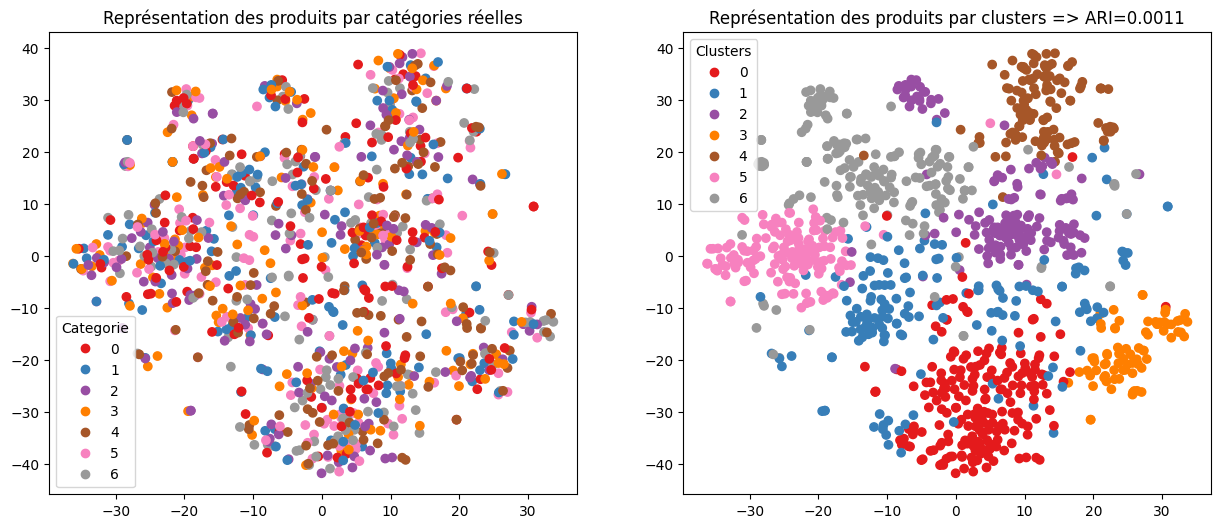

CPU times: user 9.01 s, sys: 49 ms, total: 9.06 s
Wall time: 1.75 s


In [29]:
%%time

# Détermination des clusters à partir des données reduites
k=7

cls = KMeans(n_clusters=k, n_init=100, random_state=42)
resnet_kmeans_clusters = cls.fit_predict(resnet50_X_pca)
ARI = np.round(adjusted_rand_score(data.encoded_category, resnet_kmeans_clusters),4)
results["Resnet50"] = {
    'Silhouette score': silhouette_score(resnet50_X_pca, resnet_kmeans_clusters, metric='euclidean'),
    'Davies-Bouldin score': davies_bouldin_score(resnet50_X_pca, resnet_kmeans_clusters),
    'ARI': ARI,
}
print("ARI : ", ARI)
tsne_visu_fct(resnet50_X_tsne, data.encoded_category, resnet_kmeans_clusters, ARI)

In [30]:
results

defaultdict(dict,
            {'Resnet50': {'Silhouette score': np.float32(0.04049633),
              'Davies-Bouldin score': np.float64(3.8410302072520786),
              'ARI': np.float64(0.0011)}})

In [31]:
clustered_df = pd.DataFrame(data.category, columns=['category'])
clustered_df['cluster'] = resnet_kmeans_clusters

In [32]:
clustered_df.groupby("cluster")["category"].value_counts().to_frame().reset_index()

,cluster,category,count
0,0,Watches,40
1,0,Kitchen,36
2,0,Computers,33
3,0,Beauty and Personal Care,30
4,0,Home Furnishing,26
5,0,Home Decor,23
6,0,Baby Care,22
7,1,Baby Care,31
8,1,Home Furnishing,29
9,1,Home Decor,27


In [33]:
conf_mat = confusion_matrix(data.encoded_category, clustered_df.cluster)
print(conf_mat)
print(classification_report(data.encoded_category, clustered_df.cluster))

[[22 31 20  8 18 22 29]
 [30 17 21 12 16 19 35]
 [33 22 19  9 18 25 24]
 [23 27 28 10 15 23 24]
 [26 29 28 15 16 10 26]
 [36 18 17  9 17 25 28]
 [40 19 17 13 19 19 23]]
              precision    recall  f1-score   support

           0       0.10      0.15      0.12       150
           1       0.10      0.11      0.11       150
           2       0.13      0.13      0.13       150
           3       0.13      0.07      0.09       150
           4       0.13      0.11      0.12       150
           5       0.17      0.17      0.17       150
           6       0.12      0.15      0.14       150

    accuracy                           0.13      1050
   macro avg       0.13      0.13      0.12      1050
weighted avg       0.13      0.13      0.12      1050



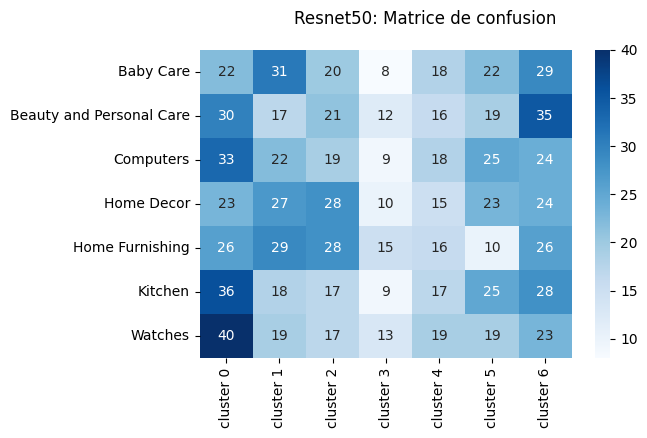

In [34]:
df_cm = pd.DataFrame(conf_mat, index = np.unique(data.category),
                  columns = [f"cluster {i}" for i in np.unique(data.encoded_category)])
plt.figure(figsize = (6,4))
sns.heatmap(df_cm, annot=True, cmap="Blues")
plt.suptitle("Resnet50: Matrice de confusion")
plt.show()

## 3.2 EXtraction des features avec VGG16

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


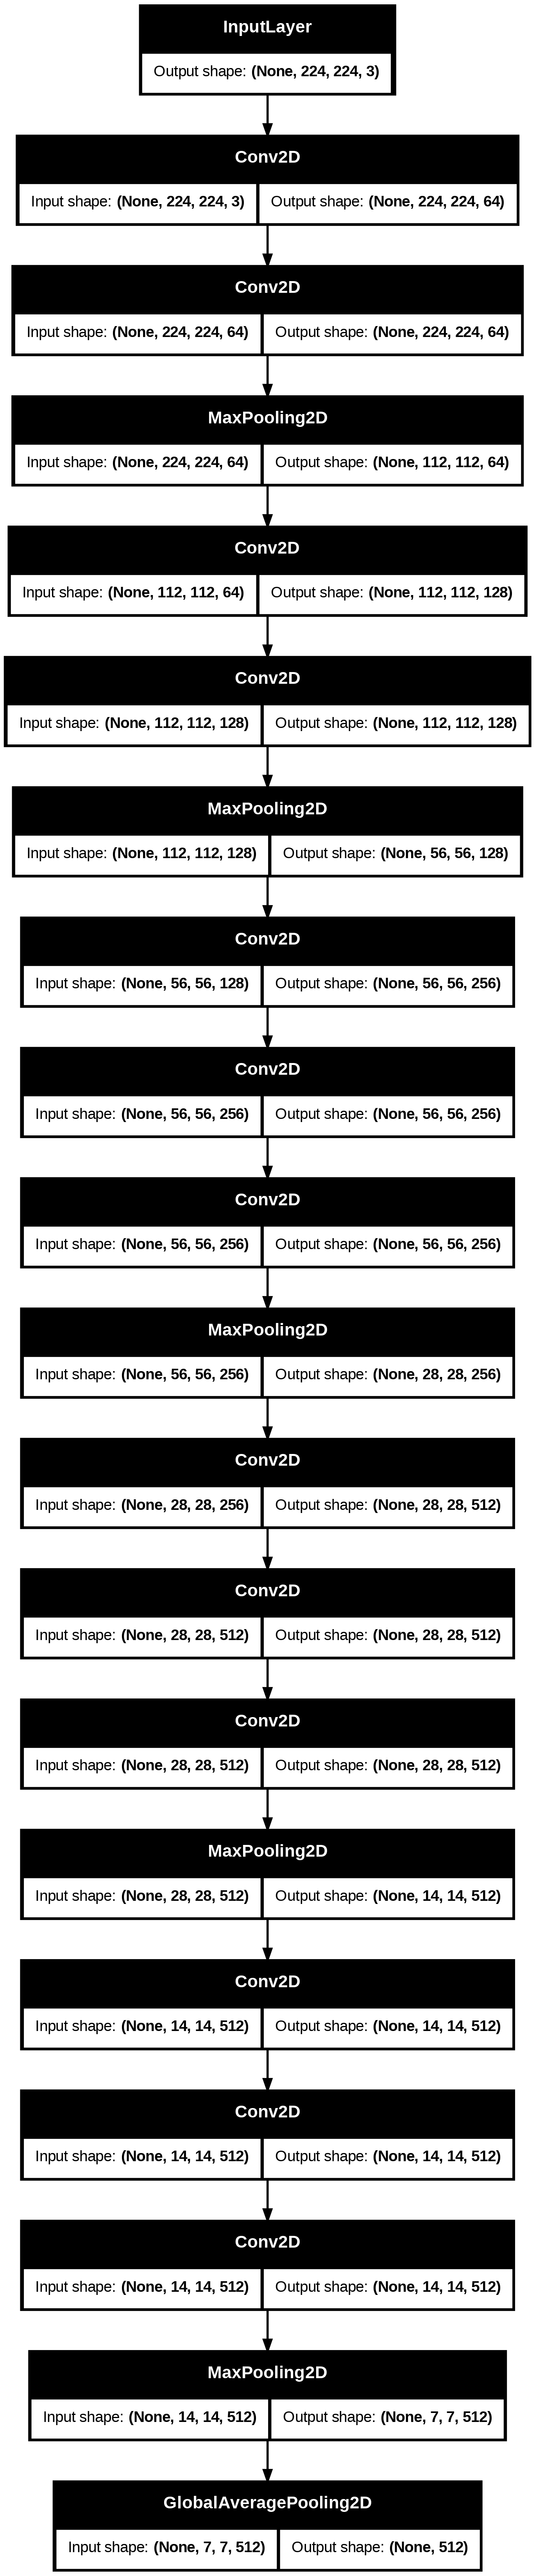

In [35]:
vgg_model = VGG16(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
tf.keras.utils.plot_model(vgg_model, show_shapes=True)

In [36]:
%%time
vgg_data_ds = data_ds.map(vgg_preprocess)
vgg_features, _ = extract_features(vgg_data_ds, vgg_model)

CPU times: user 12min 21s, sys: 2.88 s, total: 12min 24s
Wall time: 1min 37s


In [37]:
vgg_features.shape

(1050, 512)

### 3.2.1. Réduction de dimensions

#### | PCA

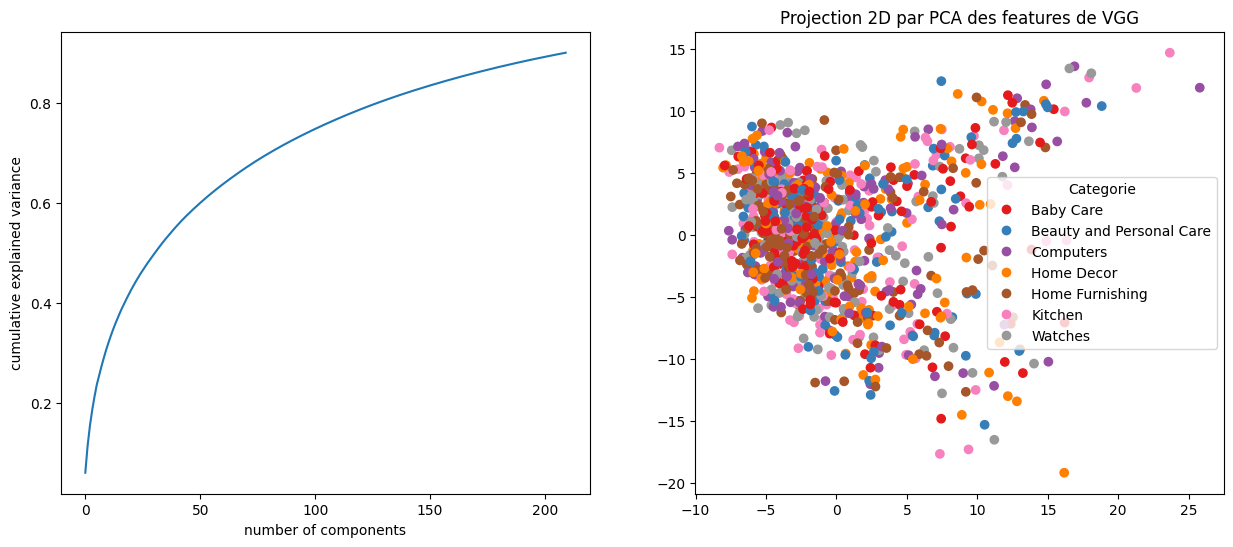

CPU times: user 1.61 s, sys: 3.31 ms, total: 1.62 s
Wall time: 333 ms


In [38]:
%%time
scaler = StandardScaler()
scaled_vgg_features = scaler.fit_transform(vgg_features)
pca = PCA(n_components=0.90)
vgg_x_pca = pca.fit_transform(scaled_vgg_features)

fig = plt.figure(figsize=(15,6))

ax = fig.add_subplot(121)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
ax = fig.add_subplot(122)

scatter = plt.scatter(vgg_x_pca[:,0],vgg_x_pca[:,1], c=data.encoded_category.tolist(), cmap='Set1')
plt.legend(handles=scatter.legend_elements()[0], labels=np.unique(data.category).tolist(), loc="best", title="Categorie")
plt.title("Projection 2D par PCA des features de VGG")
plt.show()

In [39]:
pca.components_.shape

(210, 512)

#### | T-SNE

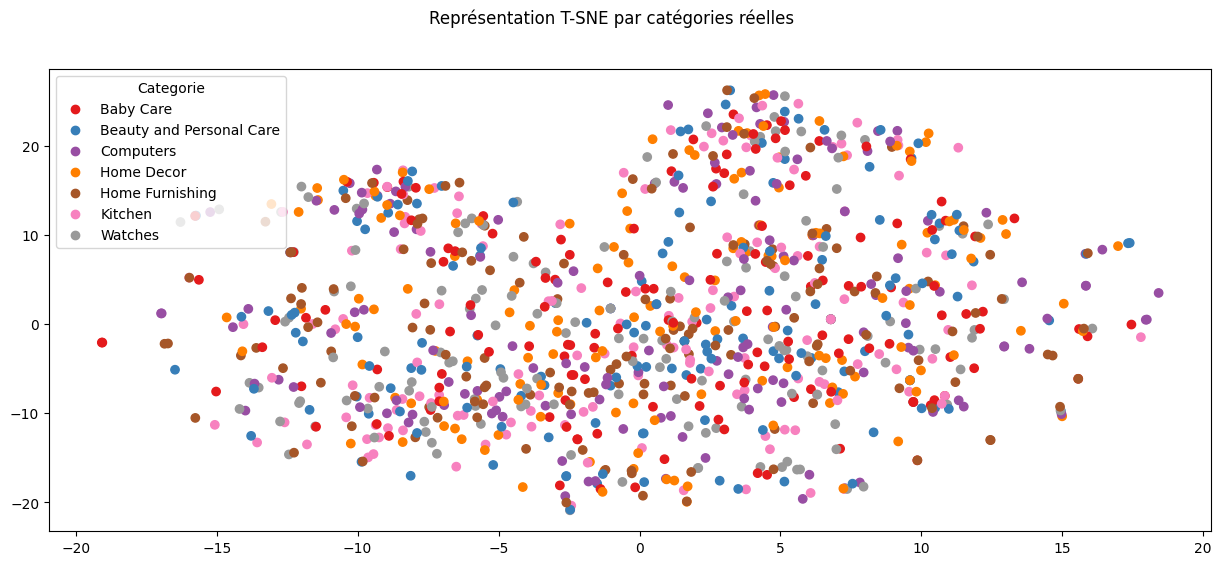

CPU times: user 16.1 s, sys: 11.7 ms, total: 16.1 s
Wall time: 4.05 s


In [40]:
%%time
fig = plt.figure(figsize=(15,6))
colors, _= pd.factorize(data.category)
tsne_data = []
tsne = TSNE(n_components=2, perplexity=70, random_state=42)
vgg_X_tsne = tsne.fit_transform(vgg_x_pca)
scatter = plt.scatter(vgg_X_tsne[:,0],vgg_X_tsne[:,1], c=data.encoded_category.tolist(), cmap='Set1')
plt.legend(handles=scatter.legend_elements()[0], labels=np.unique(data.category).tolist(), loc="best", title="Categorie")

plt.suptitle("Représentation T-SNE par catégories réelles")
plt.show()

### 3.2.2 Kmeans clustering

ARI :  0.0034


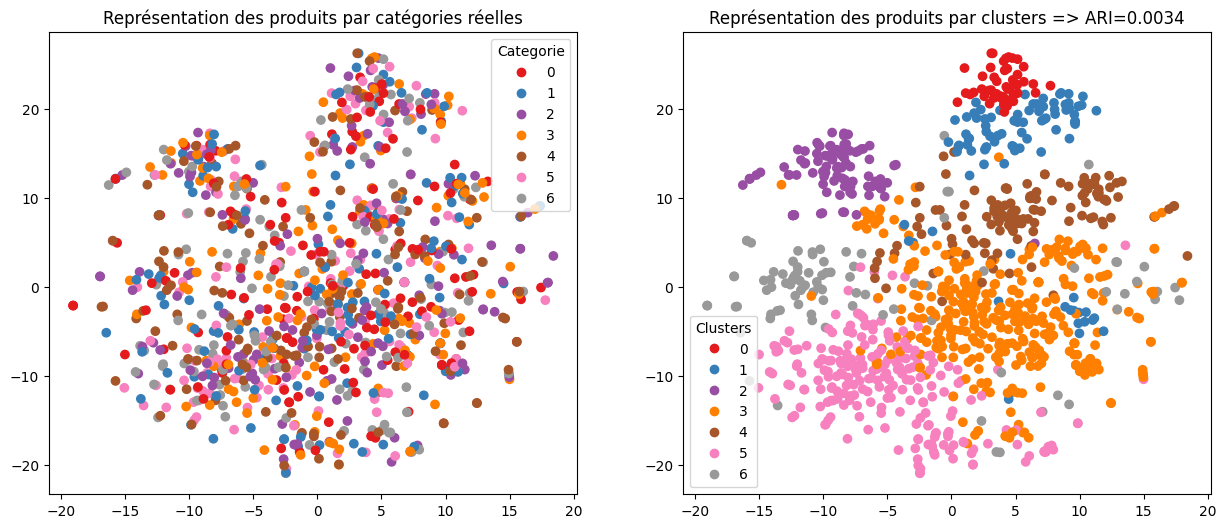

CPU times: user 1.34 s, sys: 4.77 ms, total: 1.35 s
Wall time: 384 ms


In [41]:
%%time

# Détermination des clusters à partir des données reduites
k=7
# Scaler

cls = KMeans(n_clusters=k, random_state=42)
vgg_kmeans_clusters = cls.fit_predict(vgg_x_pca)
ARI = np.round(adjusted_rand_score(data.encoded_category, vgg_kmeans_clusters),4)
results["Vgg16"] = {
    'Silhouette score': silhouette_score(vgg_x_pca, vgg_kmeans_clusters, metric='euclidean'),
    'Davies-Bouldin score': davies_bouldin_score(vgg_x_pca, vgg_kmeans_clusters),
    'ARI': ARI
}
print("ARI : ", ARI)
tsne_visu_fct(vgg_X_tsne, data.encoded_category.tolist(), vgg_kmeans_clusters, ARI)

In [42]:
clustered_df = pd.DataFrame(data.category, columns=['category'])
clustered_df['cluster'] = vgg_kmeans_clusters
clustered_df.groupby("cluster")["category"].value_counts().to_frame().reset_index()

conf_mat = confusion_matrix(data.encoded_category, clustered_df.cluster)
print(conf_mat)
print(classification_report(data.encoded_category, clustered_df.cluster))

[[ 7 17 13 61 17 20 15]
 [ 8 12 14 50 21 33 12]
 [ 8 16 17 45 18 35 11]
 [ 7 16 14 35 30 32 16]
 [ 4  7 12 63 17 30 17]
 [ 8 15 15 46 15 40 11]
 [ 6 10 15 52 15 44  8]]
              precision    recall  f1-score   support

           0       0.15      0.05      0.07       150
           1       0.13      0.08      0.10       150
           2       0.17      0.11      0.14       150
           3       0.10      0.23      0.14       150
           4       0.13      0.11      0.12       150
           5       0.17      0.27      0.21       150
           6       0.09      0.05      0.07       150

    accuracy                           0.13      1050
   macro avg       0.13      0.13      0.12      1050
weighted avg       0.13      0.13      0.12      1050



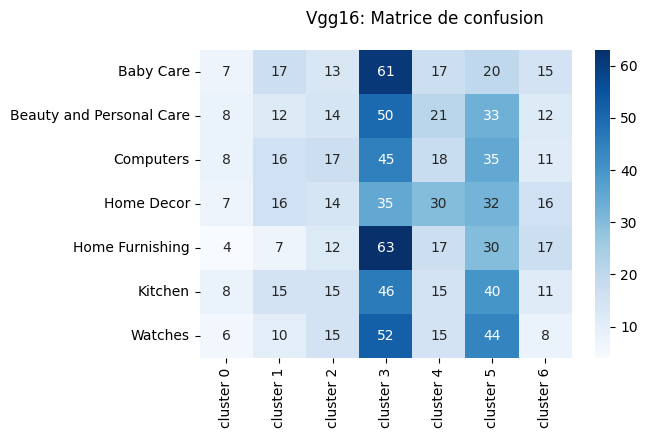

In [43]:
df_cm = pd.DataFrame(conf_mat, index = np.unique(data.category),
                  columns = [f"cluster {i}" for i in np.unique(data.encoded_category)])
plt.figure(figsize = (6,4))
sns.heatmap(df_cm, annot=True, cmap="Blues")
plt.suptitle("Vgg16: Matrice de confusion")
plt.show()

## 3.3. Comparaison

### 3.3.1 Approche visuelle

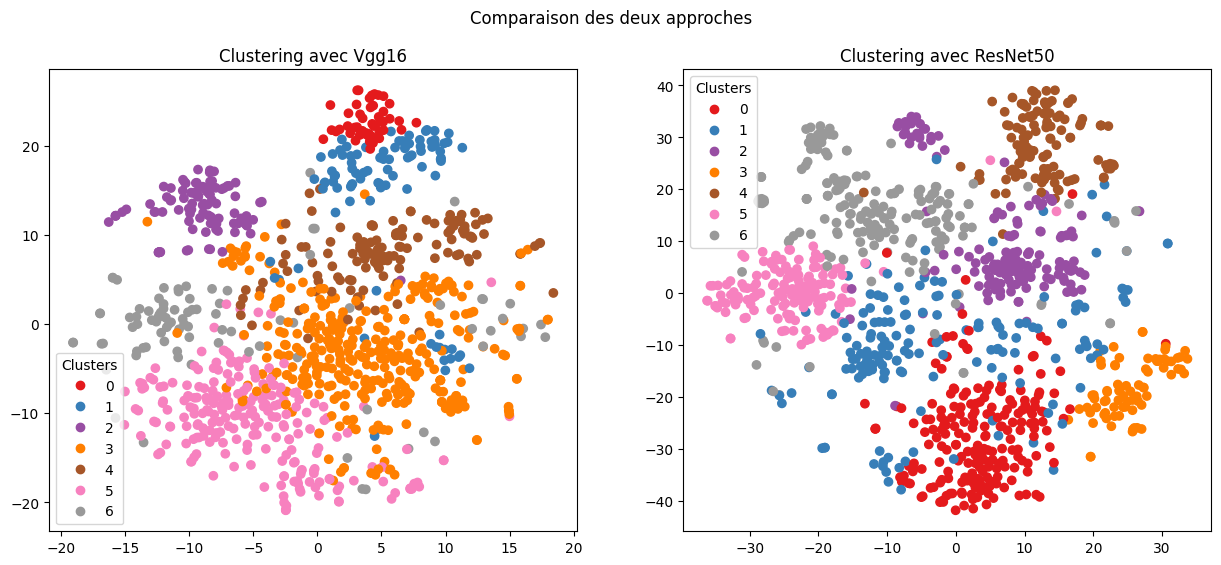

In [44]:
fig = plt.figure(figsize=(15,6))
ax = fig.add_subplot(121)


scatter = ax.scatter(vgg_X_tsne[:,0],vgg_X_tsne[:,1], c=vgg_kmeans_clusters, cmap='Set1')
ax.legend(handles=scatter.legend_elements()[0], labels=set(vgg_kmeans_clusters), loc="best", title="Clusters")
plt.title("Clustering avec Vgg16")

ax = fig.add_subplot(122)
scatter = ax.scatter(resnet50_X_tsne[:,0],resnet50_X_tsne[:,1], c=resnet_kmeans_clusters, cmap='Set1')
ax.legend(handles=scatter.legend_elements()[0], labels=set(resnet_kmeans_clusters), loc="best", title="Clusters")
plt.title("Clustering avec ResNet50")

plt.suptitle("Comparaison des deux approches")
plt.show()

### 3.3.2 Approche quantitative

- Une valeur elevée Silhouette score indique des clusters plus compacts et mieux séparés (donc un meilleur clustering).

- Une valeur faible de Davies-Bouldin score indique des clusters plus compacts et mieux séparés (donc un meilleur clustering).

In [45]:
result_df = pd.DataFrame(results).T
result_df

,Silhouette score,Davies-Bouldin score,ARI
Resnet50,0.040496,3.841030,0.0011
Vgg16,0.037813,3.217687,0.0034


🧠 Conclusion : Les features extraites par ResNet50 semblent offrir une meilleure séparation des classes que celles de VGG16 pour ce dataset. Elles sont donc plus adaptées pour un apprentissage non supervisé ou un clustering efficace dans ce cas précis.

# 4. Classification supervisée

Nous allons utilisées les features extraites à partir de notre modéle precedent de resnet50

In [46]:
train_ds = df_to_dataset(train_df, batch_size=32, shuffle=True, encoded_category=True)
validation_ds = df_to_dataset(val_df, batch_size=32, shuffle=False, encoded_category=True)
test_ds = df_to_dataset(test_df, batch_size=32, shuffle=False, encoded_category=True)

## 4.1 Augmentation du jeu d'entrainement

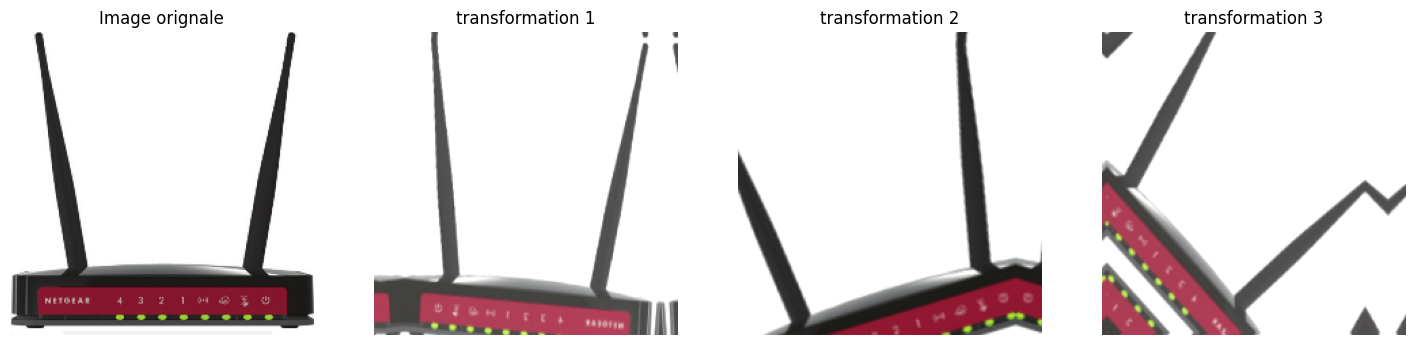

In [47]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),                       # Flip horizontal
    tf.keras.layers.RandomRotation(0.2),                            # Rotation aléatoire
    tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2),  # Zoom aléatoire
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),  # Translation aléatoire
    tf.keras.layers.RandomContrast(0.2),                            # Contraste aléatoire
    tf.keras.layers.RandomBrightness(factor=0.2),                   # Luminosité aléatoire (TF >= 2.15)
])

for image, labels in train_ds.take(1):
  plt.figure(figsize=(18, 8))
  first_image = image[0]
  k = labels[0].numpy()
  ax = plt.subplot(1, 4, 1)
  plt.imshow(first_image / 255)
  plt.title(f"Image orignale")
  plt.axis('off')
  for i in range(3):
    ax = plt.subplot(1, 4, i + 2)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.title(f"transformation {i+1}")
    plt.axis('off')

## 4.2. Modélisation

In [48]:
# Chargement du modèle ResNet50 sans la tête (top) et avec poids ImageNet
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
# Gel des couches convolutives pour ne pas les réentraîner au début
base_model.trainable = False
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,472 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, None,      │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, None,      │          0 │ conv2_block1_2_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, None,      │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, None,      │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, None,      │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [49]:
%%time
train_features, train_labels = extract_features(train_ds, base_model)
val_features, val_labels = extract_features(validation_ds, base_model)
test_features, test_labels = extract_features(test_ds, base_model)

CPU times: user 4min 16s, sys: 4.56 s, total: 4min 20s
Wall time: 44.5 s


In [50]:
print("Train features shape:", train_features.shape)
print("Validation features shape:", val_features.shape)
print("Test features shape:", test_features.shape)

Train features shape: (735, 2048)
Validation features shape: (252, 2048)
Test features shape: (63, 2048)


In [51]:
%%time
# Nouvelle tête
inputs = Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = resnet_preprocess_input(x)
x = base_model(inputs, training=False)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(7, activation='softmax')(x)

model = Model(inputs, outputs)

CPU times: user 38.6 ms, sys: 92 µs, total: 38.6 ms
Wall time: 35.6 ms


In [52]:
%%time
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.3758 - loss: 1.9383 - val_accuracy: 0.7143 - val_loss: 0.8643
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7686 - loss: 0.6977 - val_accuracy: 0.8214 - val_loss: 0.6827
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8387 - loss: 0.4615 - val_accuracy: 0.7976 - val_loss: 0.6840
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9005 - loss: 0.3625 - val_accuracy: 0.8214 - val_loss: 0.6310
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9109 - loss: 0.2552 - val_accuracy: 0.8214 - val_loss: 0.6360
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9281 - loss: 0.2491 - val_accuracy: 0.8294 - val_loss: 0.6469
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9331 - loss: 0.2268 - val_accuracy: 0.8294 - val_loss: 0.6199
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9616 - loss: 0.1419 - val_accuracy: 0.8016 - val_loss:

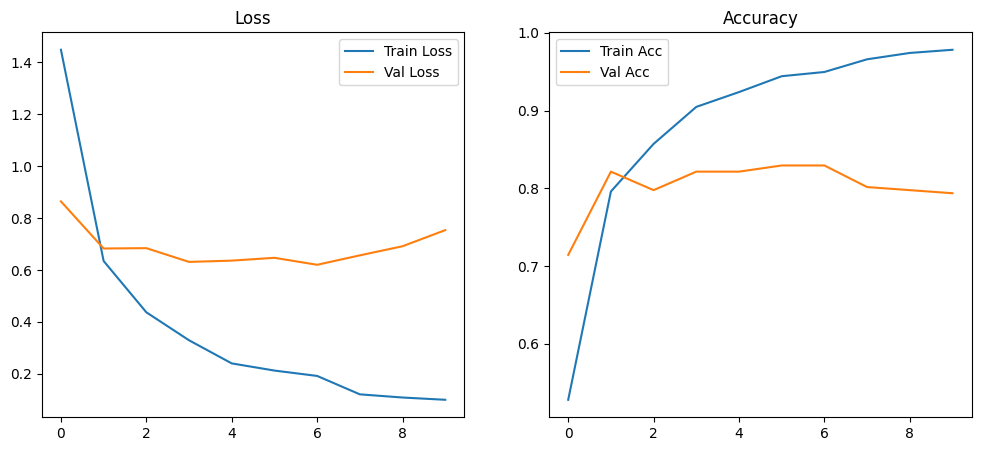

Test dataset evaluation
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 906ms/step - accuracy: 0.7579 - loss: 1.1106


[1.1013821363449097, 0.761904776096344]

In [53]:
# Courbes Loss/Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()
print("Test dataset evaluation")
model.evaluate(test_ds)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 149s 5s/step - accuracy: 0.7631 - loss: 0.7477 - val_accuracy: 0.8651 - val_loss: 0.5801
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 115s 5s/step - accuracy: 0.9429 - loss: 0.2324 - val_accuracy: 0.8571 - val_loss: 0.5784
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 117s 5s/step - accuracy: 0.9630 - loss: 0.1342 - val_accuracy: 0.8532 - val_loss: 0.5637
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 118s 5s/step - accuracy: 0.9818 - loss: 0.0974 - val_accuracy: 0.8452 - val_loss: 0.5521
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 118s 5s/step - accuracy: 0.9911 - loss: 0.0738 - val_accuracy: 0.8492 - val_loss: 0.5542
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 116s 5s/step - accuracy: 0.9956 - loss: 0.0539 - val_accuracy: 0.8413 - val_loss: 0.5584
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 114s 5s/step - accuracy: 0.9998 - loss: 0.0455 - val_accuracy: 0.8413 - val_loss: 0.5612


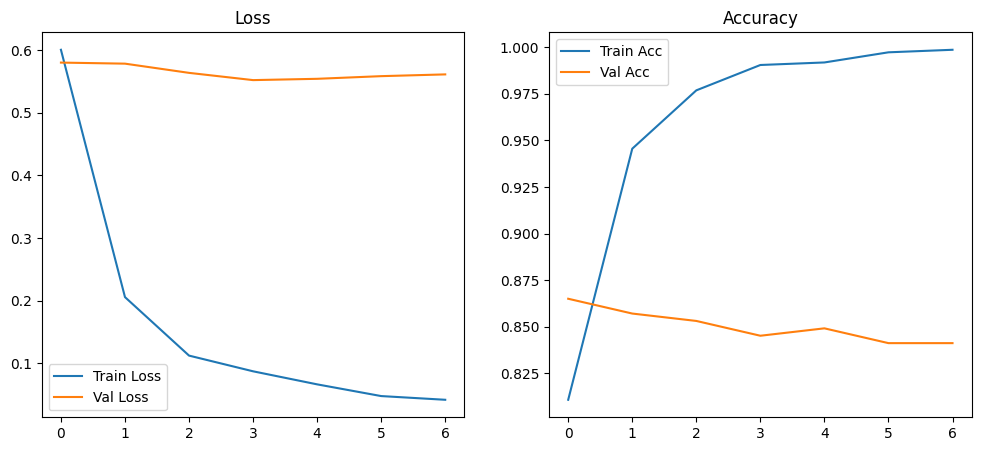

CPU times: user 1h 26min 52s, sys: 9min 23s, total: 1h 36min 15s
Wall time: 14min 7s


In [54]:
%%time
# Degeler toutes les couches base model
base_model.trainable = True

model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
]

h = model.fit(train_ds, epochs=20, validation_data=validation_ds, callbacks=callbacks)

# Courbes Loss/Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(h.history['loss'], label='Train Loss')
plt.plot(h.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h.history['accuracy'], label='Train Acc')
plt.plot(h.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

In [55]:
print("Test dataset evaluation")
model.evaluate(test_ds)

Test dataset evaluation
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 937ms/step - accuracy: 0.8527 - loss: 0.6826


[0.6655263304710388, 0.8571428656578064]

## 4.3. Interprétation

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []
images = []


for batch_images, batch_labels in test_ds:
    preds = model.predict(batch_images, verbose=0)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    images.extend(batch_images.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
images = np.array(images)

# Générer noms de classes automatiquement à partir des labels uniques triés
unique_labels = sorted(np.unique(y_true))
class_names = [c for c in np.unique(test_df.category.values)]

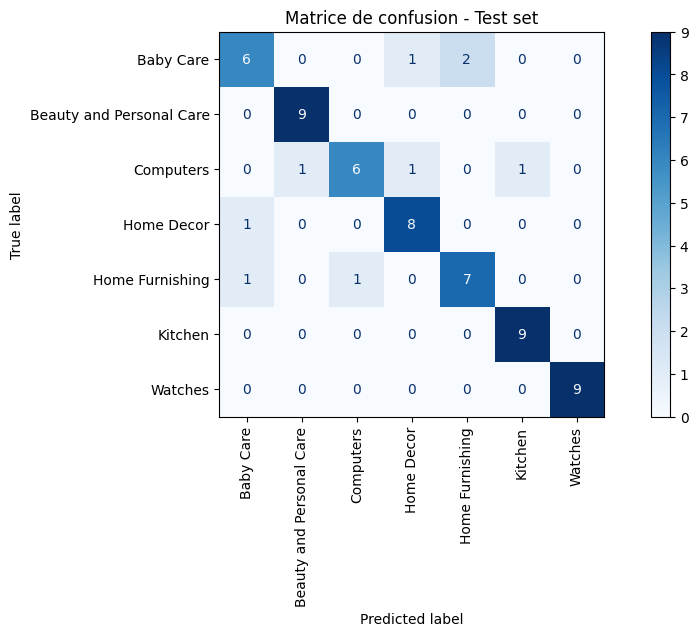

In [57]:
#fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
fig = plt.figure(figsize=(12, 5))
ax_cm = fig.add_subplot(111)
cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax_cm, xticks_rotation=90)
ax_cm.set_title("Matrice de confusion - Test set")
plt.show()

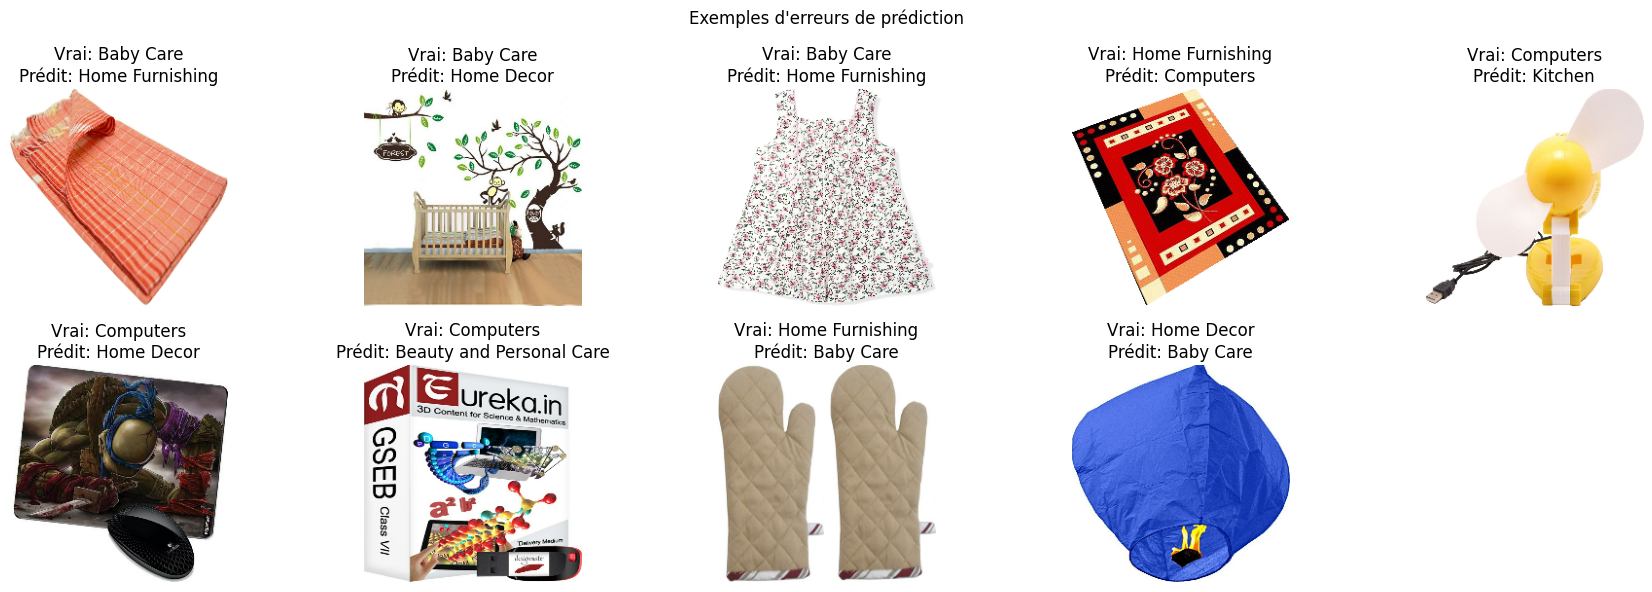

In [58]:
fig = plt.figure(figsize=(18, 6))

wrong_idx = np.where(y_pred != y_true)[0]

for i, idx in enumerate(wrong_idx):
    ax = fig.add_subplot(2, 5, i + 1)
    ax.imshow(images[idx].astype("uint8"))
    ax.set_title(f"Vrai: {class_names[y_true[idx]]}\nPrédit: {class_names[y_pred[idx]]}")
    ax.axis("off")

plt.suptitle("Exemples d'erreurs de prédiction")
plt.tight_layout()
plt.show()